# Discrete-shell window check (identity continuous $W$)

This notebook demonstrates how the window function in `meer21cm.window` can take into account the effect of discrete $|k|$-shell sampling. For details of how the window function in `meer21cm` is constructed, see the descriptions in [API summary](https://meer21cm.readthedocs.io/en/latest/meer21cm.html#module-meer21cm.window)

Here we use the simulation box with uniform weights, **no** beam / map sampling / MAS compensation.

1. Discrete shell multipoles of $P(k,\mu)$ on the FFT grid (`P_disc`). Both mock and model can be evaluated at the 3D level when assuming global los plane-parallel.
2. Continuous $P_\ell(k_\mathrm{in})$ via `get_theory_multipoles_kmu`
3. $W_{\ell i,\,\ell' j}$ with `continuous='identity'` (no survey convolution; $|k|$-shell rebin of $P_\ell$)
4. $P_\mathrm{win}=W\cdot P_\ell(k_\mathrm{in})$ should track `P_disc`

Identity $W$ means no survey convolution. The outer discrete-shell sum still reconstructs $P(k,\mu)=\sum_{\ell'}P_{\ell'}(|k|)\,\mathcal{L}_{\ell'}(\mu)$ on each FFT mode and bins with $(2\ell+1)\mathcal{L}_\ell(\mu)$, the same projector as `get_1d_power`. Evaluating continuous $P_\ell$ only at the bin centre $k_\mathrm{out}$ skips that sampling and should look worse.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from meer21cm import MockSimulation
from meer21cm.util import redshift_to_freq
from meer21cm.window import build_discrete_shell_window_matrix


In [2]:
# build simple simulation
z_min, z_max = 0.6, 0.8
nu_arr = np.linspace(redshift_to_freq(z_max), redshift_to_freq(z_min), 100)
mock = MockSimulation(
    ra_range=(0, 20),
    dec_range=(-20, 20),
    nu=nu_arr,
    hp_nside=128,
    mean_amp_1=1.0,
    density="gaussian",
    include_beam=[False, False],
    include_sky_sampling=[False, False],
    compensate=[False, False],
    sigma_v_1=200,
    
)
mock.k1dbins = np.linspace(0.01, 0.25, 11)
mock.field_1 = mock.mock_tracer_field_1

# the window matrix is Yamamoto-only (local LOS); use a far observer so
# n̂_ref ≈ ẑ and the discrete-μ projector equals μ_z (get_1d_power)
mock.los = "endpoint"
mock.los_observer = np.array([0.0, 0.0, 1.0e12])


In [3]:
# get the 3D to 1D exact averaging
ells = (0, 2, 4)
k1dbins = mock.k1dbins
shell = mock.multipole_bin_index_map(k1dbins=k1dbins)

# Discrete shells of bare P(k,μ)
p3d_model = mock.power_kmu("auto_1", include_mean_amp=True)
p3d_mock = mock.auto_power_3d_1
P_disc_model = {}
P_disc_mock = {}
for ell in ells:
    P_disc_model[ell], keff_disc, _ = mock.get_1d_power(p3d_model, multipole_ell=ell)
    P_disc_mock[ell], keff_disc, _ = mock.get_1d_power(p3d_mock, multipole_ell=ell)


In [4]:
# get the continuous $P_\ell(k_\mathrm{in})$ assuming uniform mu spherical average, on a finer k-grid
k_in = np.geomspace(max(float(k1dbins[0]) * 0.5, 1e-3), float(k1dbins[-1]) * 1.5, 80)
cont_fine = mock.get_theory_multipoles_kmu(k_in, ells=ells, nmu=64, which="auto_1")
cont_out = mock.get_theory_multipoles_kmu(shell.k_eff, ells=ells, nmu=64, which="auto_1")
# then build the window matrix for the discrete k-shell sampling over the 3D grid
mat = build_discrete_shell_window_matrix(
    shell, k_in=k_in, ells=ells, continuous="identity", n_k_eval=128
)
P_win = mat.apply(cont_fine["P_ell"])


ell=0 median |P_win - P_disc_model| / |P_disc_model| = 0.0022326827115529174
ell=0 median |cont_out - P_disc_model| / |P_disc_model| (should be worse) = 0.0533114927676471
ell=2 median |P_win - P_disc_model| / |P_disc_model| = 0.0024952373412532834
ell=2 median |cont_out - P_disc_model| / |P_disc_model| (should be worse) = 0.49731831075056426
ell=4 median |P_win - P_disc_model| / |P_disc_model| = 0.0028504702750133974
ell=4 median |cont_out - P_disc_model| / |P_disc_model| (should be worse) = 0.8530602792207864


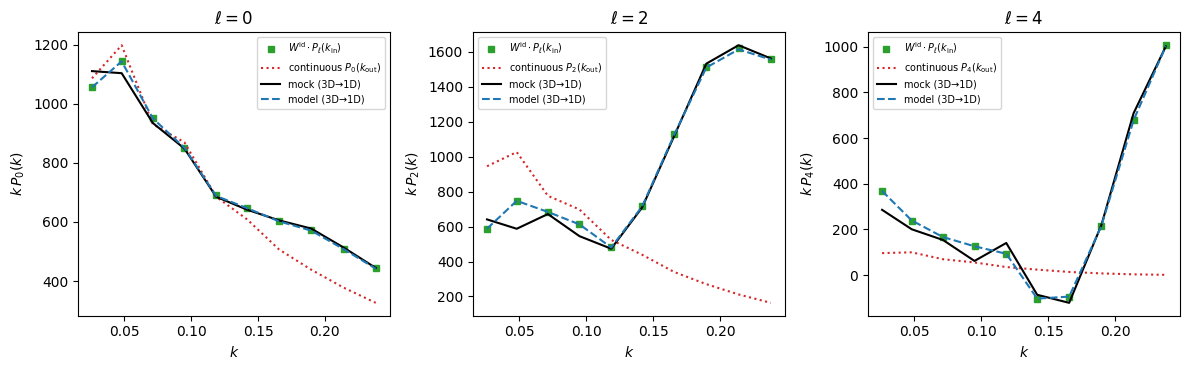

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
for ax, ell in zip(axes, ells):
    ax.plot(
        mat.k_out,
        P_win[ell] * mat.k_out,
        "C2s",
        ms=5,
        label=r"$W^\mathrm{id}\cdot P_\ell(k_\mathrm{in})$",
    )
    ax.plot(
        cont_out["k"],
        cont_out["P_ell"][ell] * cont_out["k"],
        "C3:",
        label=r"continuous $P_%d(k_\mathrm{out})$" % ell,
    )
    
    ax.plot(keff_disc, P_disc_mock[ell] * keff_disc, "k-", lw=1.5, label="mock (3D→1D)")
    ax.plot(keff_disc, P_disc_model[ell] * keff_disc, "C0--", lw=1.5, label="model (3D→1D)")
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$k\,P_%d(k)$" % ell)
    ax.legend(fontsize=7)
    ax.set_title(r"$\ell=%d$" % ell)
fig.tight_layout()

for ell in ells:
    m = np.isfinite(P_win[ell]) & np.isfinite(P_disc_mock[ell]) & (np.abs(P_disc_mock[ell]) > 0)
    print(
        "ell=%d median |P_win - P_disc_model| / |P_disc_model| =" % ell,
        np.nanmedian(np.abs(P_win[ell][m] - P_disc_model[ell][m]) / np.abs(P_disc_model[ell][m])),
    )
    print(
        "ell=%d median |cont_out - P_disc_model| / |P_disc_model| (should be worse) =" % ell,
        np.nanmedian(
            np.abs(cont_out["P_ell"][ell][m] - P_disc_model[ell][m]) / np.abs(P_disc_model[ell][m])
        ),
    )



Note a few things here:
1. P0, P2 and P4 for mock and theory (black and blue lines) are not the same as the continuous models (red lines). These are purely the effects of $\mu$ sampling
2. The window convolved model (green squares) does not have any weighting correction (the continuous part of the window function is just diagonal). In this uniform global-PP box it should track the 3D→1D points, not the red curves.

We can visualise the window function matrix for one k-mode:

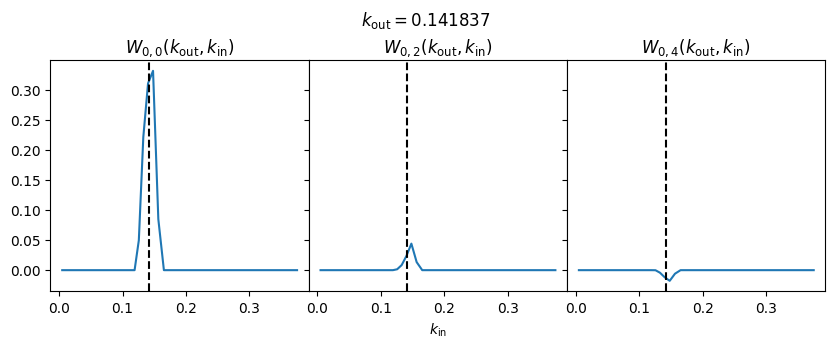

In [6]:
from meer21cm.plot import plot_discrete_shell_window_row

fig, axes = plot_discrete_shell_window_row(mat, k_out_index=5)

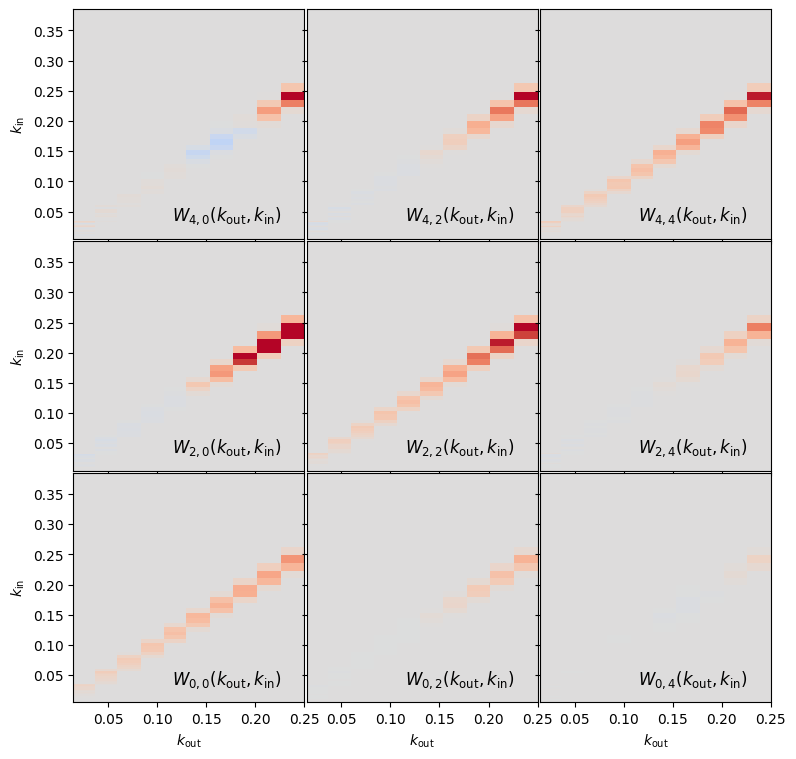

In [7]:
from meer21cm.plot import plot_discrete_shell_window_matrix

fig, axes = plot_discrete_shell_window_matrix(mat)

Note that k_in usually has finer spacing and more range than k_out, hence the plot does not appear very diagonal, but actually is quite close to diagonal for W_00